# SAP Extended Passport (EPP)

Extended Passports are shared records carried by several SAP protocols. The same binary `SAPEPP` structure can appear in SAP Diag, classic RFC, and NWRFC; HTTP transports its hexadecimal representation in the `SAP-PASSPORT` header. Carrier notebooks describe their respective envelopes.

In [1]:
from pysap.SAPEPP import (
    SAPEPP, SAPEPPItem, SAPEPPVariablePart,
    epp_from_http_header, epp_to_http_header,
)
from IPython.display import display

## Version 3 record and variable items

Version 3 extends the fixed EPP core with client and context fields plus zero or more variable parts. Item values remain raw bytes so unknown or malformed captures can be parsed and rebuilt without normalization.

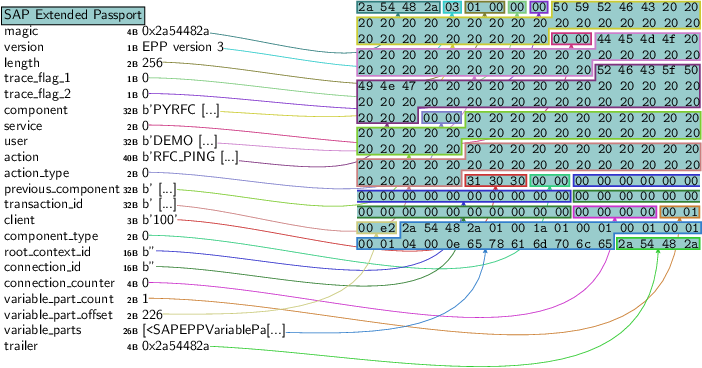

Encoded length: 256


In [2]:
passport = SAPEPP(
    component=b"PYRFC", user=b"DEMO", action=b"RFC_PING", client=b"100",
    variable_parts=[SAPEPPVariablePart(
        last=1, part_id=1,
        items=[SAPEPPItem(key=1, application=1, item_type=4, value=b"example")],
    )],
)
display(passport.canvas_dump())
print("Encoded length:", len(bytes(passport)))

## Parse and rebuild

Parsing selects the version-specific fields and counted variable parts. A normal record rebuilds byte-for-byte.

In [3]:
encoded = bytes(passport)
parsed = SAPEPP(encoded)
assert bytes(parsed) == encoded
print(parsed.component.rstrip(b"\x00 "))
print(parsed.variable_parts[0].items[0].value)

b'PYRFC'
b'example'


## HTTP `SAP-PASSPORT` header

pysap does not implement HTTP framing. These helpers only convert between EPP bytes and the hexadecimal header value used by an HTTP client or server.

In [4]:
header_value = epp_to_http_header(passport)
decoded = epp_from_http_header(header_value)
assert bytes(decoded) == bytes(passport)
print("SAP-PASSPORT:", header_value)

SAP-PASSPORT: 2a54482a03010000005059524643202020202020202020202020202020202020202020202020202020000044454d4f202020202020202020202020202020202020202020202020202020205246435f50494e4720202020202020202020202020202020202020202020202020202020202020200000202020202020202020202020202020202020202020202020202020202020202020202020202020202020202020202020202020202020202020202020202020203130300000000000000000000000000000000000000000000000000000000000000000000000000000000100e22a54482a01001a01000100010001000104000e6578616d706c652a54482a
